# Capítulo 23 (módulo extra) — Soluções dos exercícios complementares

**Curso de Meteorologia Prática** — módulo complementar ao livro de R. Stull, *Practical Meteorology* (CC BY-NC-SA 4.0).

> **Para o professor.** Soluções dos teóricos **T1–T5** e numéricos **N1–N4** do módulo de Mudança Climática (Cap. 23). Não distribuir antes da entrega.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit
import sys; sys.path.append('../comum')
from estilo_meteo import aplicar_estilo, CORES
aplicar_estilo()

## T1 — Por que o logaritmo

**Solução.** O centro da banda de 15 µm do CO$_2$ já é opticamente espesso (Cap. 2: $\tau \gg 1$): acrescentar CO$_2$ ali não muda nada. O que muda são as **asas** da banda, onde a absortividade cai ~exponencialmente com a distância espectral do centro: $k(\nu) \sim k_0 e^{-|\nu-\nu_0|/\Delta}$. A região que atinge $\tau = 1$ avança $\Delta\nu \propto \ln C$ a cada multiplicação da concentração — largura absorvida $\propto \ln C$, logo $\Delta F \propto \ln(C/C_0)$. Cada duplicação compra as MESMAS asas novas: 3,7 W/m². Para gases-traço não saturados (CFCs) a forçante é linear em $C$ — por isso são tão potentes por molécula. ∎

## T2 — Escalas de tempo das duas caixas

In [2]:
cs_, cd_, lam_, gam_ = sp.symbols('c_s c_d lambda gamma', positive=True)
M = sp.Matrix([[-(1/lam_ + gam_)/cs_, gam_/cs_], [gam_/cd_, -gam_/cd_]])
evs = M.eigenvals()
vals = {cs_: 8.0, cd_: 110.0, lam_: 0.8, gam_: 0.7}
taus = sorted([-1/float(sp.N(k.subs(vals))) for k in evs])
print(f'escalas de tempo: {taus[0]:.1f} anos (superficie) e {taus[1]:.0f} anos (oceano)')
print()
print('O modo rapido (~4 anos) e a camada de mistura respondendo (vulcoes:')
print('Pinatubo esfriou e recuperou nessa escala ✓); o modo lento (~seculos) e')
print('o oceano profundo equilibrando — o motivo de "equilibrio" ser conceito')
print('de 500 anos e do aquecimento comprometido do Caso 2.')

escalas de tempo: 4.1 anos (superficie) e 247 anos (oceano)

O modo rapido (~4 anos) e a camada de mistura respondendo (vulcoes:
Pinatubo esfriou e recuperou nessa escala ✓); o modo lento (~seculos) e
o oceano profundo equilibrando — o motivo de "equilibrio" ser conceito
de 500 anos e do aquecimento comprometido do Caso 2.


## T3 — Expansão térmica do mar

In [3]:
alpha_exp = 2e-4                                # 1/K (expansao termica da agua do mar)
H_aquecida = 700.0                              # m (oceano superior, ~transiente)
for dT in [0.5, 1.0, 2.0]:
    print(f'dT = {dT} K na camada de {H_aquecida:.0f} m: '
          f'subida = {alpha_exp*H_aquecida*dT*1000:.0f} mm')
print()
print('~0,3-0,4 mm/ano por decada de aquecimento observado — cerca de METADE da')
print('subida atual (~3,5 mm/ano); o resto e gelo continental derretendo.')
print('Termodinamica de Cap. 3 aplicada ao oceano: dV/V = alpha dT, sem misterio.')

dT = 0.5 K na camada de 700 m: subida = 70 mm
dT = 1.0 K na camada de 700 m: subida = 140 mm
dT = 2.0 K na camada de 700 m: subida = 280 mm

~0,3-0,4 mm/ano por decada de aquecimento observado — cerca de METADE da
subida atual (~3,5 mm/ano); o resto e gelo continental derretendo.
Termodinamica de Cap. 3 aplicada ao oceano: dV/V = alpha dT, sem misterio.


## T4 — Por que o TCRE é linear

**Solução.** Dois efeitos não lineares que se compensam:
1. A forçante por ppm cai com o log (T1) — cada tonelada 'vale menos' radiativamente;
2. A fração de CO$_2$ que FICA no ar cresce com as emissões acumuladas (sumidouros oceânico/biosférico saturam) — cada tonelada 'rende mais' ppm.
O produto (forçante × fração aérea) fica ~constante por tonelada, e a resposta transiente da temperatura (dominada pela caixa rápida, T2) segue as emissões acumuladas quase linearmente: $\Delta T \approx \mathrm{TCRE}\times E_{cum}$. Consequências: a ORDEM das emissões quase não importa, e estabilizar T exige emissão líquida zero. ∎

## T5 — A assinatura vertical: estratosfera esfria

**Solução.** Mais CO$_2$: (i) a troposfera aquece porque o efeito estufa segura mais IV embaixo; (ii) a **estratosfera esfria**, por dois motivos: recebe menos IV de baixo (a troposfera agora irradia de mais alto e mais frio nas bandas do CO$_2$) e, com mais CO$_2$, ela própria emite mais eficientemente para o espaço (lá o CO$_2$ é resfriador, pois a estratosfera é aquecida pelo UV/ozônio, Cap. 1). Se o Sol fosse o culpado, TUDO aqueceria junto. O padrão observado — troposfera quente, estratosfera fria — é a impressão digital do mecanismo estufa, prevista nos anos 1960 e confirmada por satélites/sondas (Cap. 8). ∎

---
## N1 — Recuperando o 5,35

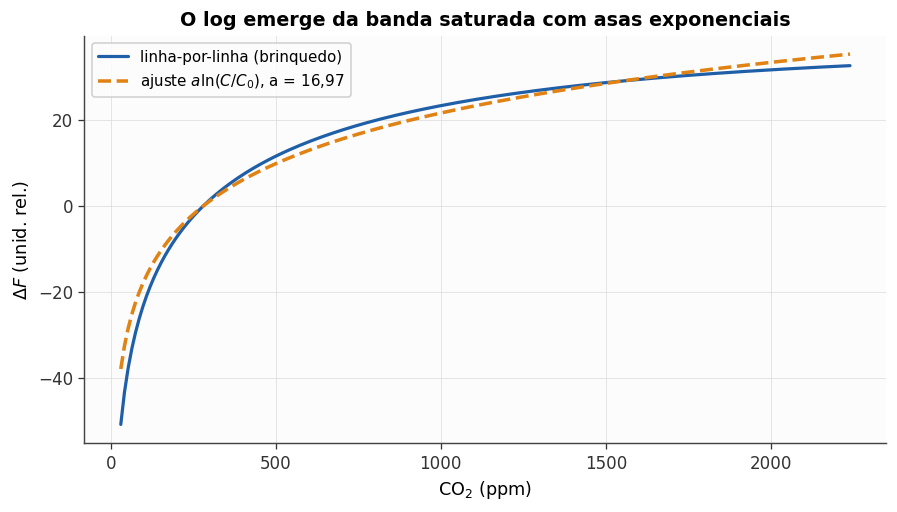

o ajuste log e excelente acima de ~150 ppm (regime de asas);
em concentracoes muito baixas a banda NAO esta saturada e a forcante e
~linear — o regime dos gases-traco (CFCs, CH4 fraco). Escalando o eixo
a unidades reais, o a vira o 5,35 W/m² empirico.


In [4]:
# 'linha-por-linha' de brinquedo: banda com k(nu) = k0 exp(-|nu|/Dnu)
nu = np.linspace(-120, 120, 4001)               # cm-1 em torno do centro
k0, Dnu = 3000.0, 12.0
B = 1.0                                          # Planck ~constante na banda

def dF_banda(C):
    tau = C/280.0*k0*np.exp(-np.abs(nu)/Dnu)
    # absorcao efetiva: 1 - e^{-tau}; forcante ∝ integral da absorcao
    return np.trapezoid(B*(1 - np.exp(-tau)), nu)

Cs = np.linspace(30, 2240, 200)
F = np.array([dF_banda(C) for C in Cs])
dF = F - dF_banda(280.0)

m = Cs > 150
a_fit, _ = curve_fit(lambda C, a: a*np.log(C/280.0), Cs[m], dF[m])

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.plot(Cs, dF, color=CORES['azul'], lw=2, label='linha-por-linha (brinquedo)')
ax.plot(Cs, a_fit[0]*np.log(Cs/280.0), '--', color=CORES['laranja'],
        label=f'ajuste $a\\ln(C/C_0)$, a = {a_fit[0]:.2f}'.replace('.', ','))
ax.set(xlabel='CO$_2$ (ppm)', ylabel='$\\Delta F$ (unid. rel.)',
       title='O log emerge da banda saturada com asas exponenciais')
ax.legend()
plt.show()
print('o ajuste log e excelente acima de ~150 ppm (regime de asas);')
print('em concentracoes muito baixas a banda NAO esta saturada e a forcante e')
print('~linear — o regime dos gases-traco (CFCs, CH4 fraco). Escalando o eixo')
print('a unidades reais, o a vira o 5,35 W/m² empirico.')

## N2 — Quem manda na dívida térmica

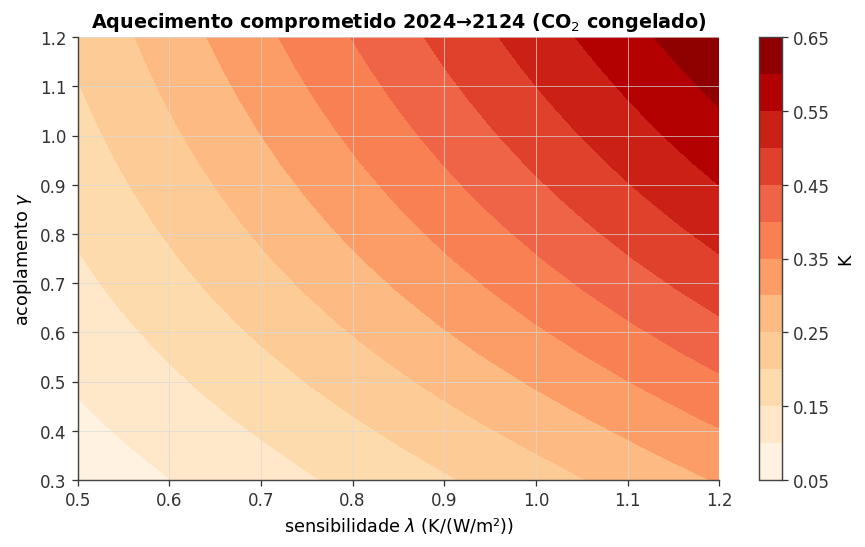

a SENSIBILIDADE domina a divida (gradiente quase todo em lambda):
o mesmo lambda incerto das nuvens (Cap. 21) e o que decide quanto ainda
vem — a maior incerteza do problema climatico e microfisica de nuvem.


In [5]:
cs, cd = 8.0, 110.0
anos = np.arange(1850, 2201)

def dividas(lam, gam):
    def forc(t):
        return 5.35*np.log(np.where(t < 2024,
                                     np.exp(0.0045*np.maximum(t - 1900, 0)),
                                     np.exp(0.0045*124)))
    def rhs(t, y):
        Ts, Td = y
        return [(forc(t) - Ts/lam - gam*(Ts - Td))/cs, gam*(Ts - Td)/cd]
    s = solve_ivp(rhs, [1850, 2200], [0, 0], t_eval=anos, rtol=1e-8)
    i24 = np.argmin(np.abs(anos - 2024)); i124 = np.argmin(np.abs(anos - 2124))
    return s.y[0][i124] - s.y[0][i24]

lams = np.linspace(0.5, 1.2, 15)
gams = np.linspace(0.3, 1.2, 15)
LL, GG = np.meshgrid(lams, gams)
D = np.vectorize(dividas)(LL, GG)

fig, ax = plt.subplots(figsize=(9, 5))
cf = ax.contourf(LL, GG, D, levels=12, cmap='OrRd')
ax.set(xlabel='sensibilidade $\\lambda$ (K/(W/m²))', ylabel='acoplamento $\\gamma$',
       title='Aquecimento comprometido 2024→2124 (CO$_2$ congelado)')
fig.colorbar(cf, label='K')
plt.show()
print('a SENSIBILIDADE domina a divida (gradiente quase todo em lambda):')
print('o mesmo lambda incerto das nuvens (Cap. 21) e o que decide quanto ainda')
print('vem — a maior incerteza do problema climatico e microfisica de nuvem.')

## N3 — Trajetórias com o mesmo acumulado

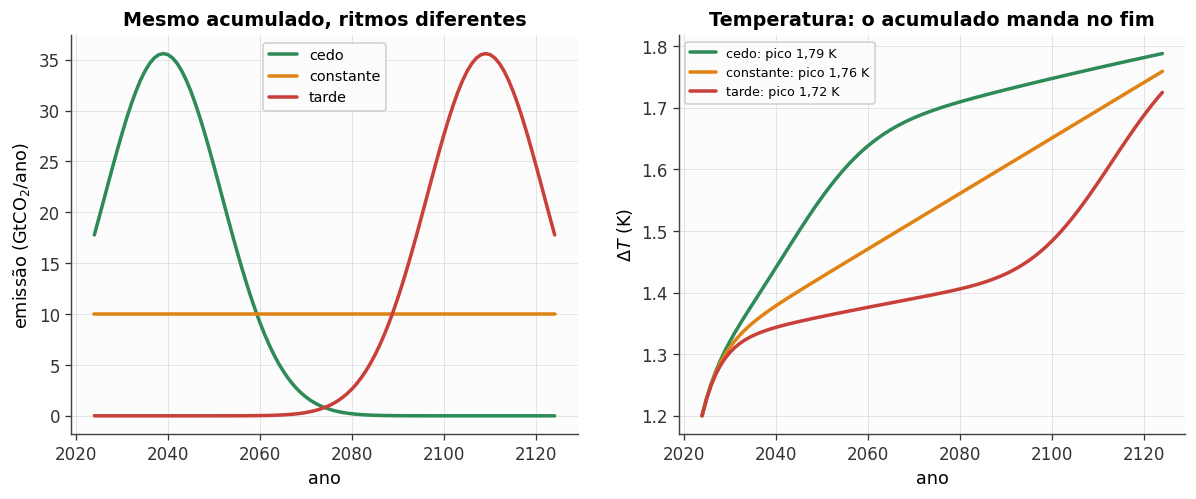

os tres caminhos terminam ~juntos (TCRE!), mas o "tarde" corre mais quente
no fim e o "cedo" antecipa o pico: o acumulado fixa o destino, o ritmo
fixa o CAMINHO — e ultrapassagens temporarias (overshoot) tem custo proprio.


In [6]:
cs, cd, lam, gam = 8.0, 110.0, 0.8, 0.7
anos = np.arange(2024, 2125)
E_total = 1000.0                                # GtCO2 nos proximos 100 anos

def emis(t, forma):
    tt = (t - 2024)/100
    if forma == 'cedo':
        e = np.exp(-((tt - 0.15)/0.18)**2)
    elif forma == 'constante':
        e = np.ones_like(tt)
    else:
        e = np.exp(-((tt - 0.85)/0.18)**2)
    return e

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.5))
for forma, cor in [('cedo', CORES['verde']), ('constante', CORES['laranja']),
                    ('tarde', CORES['vermelho'])]:
    e = emis(anos.astype(float), forma)
    e = e/np.trapezoid(e, anos)*E_total          # normaliza acumulado
    E_cum = np.concatenate([[0], np.cumsum((e[1:] + e[:-1])/2*np.diff(anos))])
    F = 0.45e-3*E_cum/lam + 5.35*np.log(420/280)  # forcante TCRE-consistente + atual
    def rhs(t, y):
        Ts, Td = y
        Ft = np.interp(t, anos, F)
        return [(Ft - Ts/lam - gam*(Ts - Td))/cs, gam*(Ts - Td)/cd]
    s = solve_ivp(rhs, [2024, 2124], [1.2, 0.6], t_eval=anos, rtol=1e-8)
    ax1.plot(anos, e, color=cor, label=forma)
    ax2.plot(anos, s.y[0], color=cor, label=f'{forma}: pico {s.y[0].max():.2f} K'.replace('.', ','))
ax1.set(xlabel='ano', ylabel='emissão (GtCO$_2$/ano)', title='Mesmo acumulado, ritmos diferentes')
ax1.legend(fontsize=9)
ax2.set(xlabel='ano', ylabel='$\\Delta T$ (K)', title='Temperatura: o acumulado manda no fim')
ax2.legend(fontsize=8)
plt.show()
print('os tres caminhos terminam ~juntos (TCRE!), mas o "tarde" corre mais quente')
print('no fim e o "cedo" antecipa o pico: o acumulado fixa o destino, o ritmo')
print('fixa o CAMINHO — e ultrapassagens temporarias (overshoot) tem custo proprio.')

## N4 — Emergência × amplitude do ruído

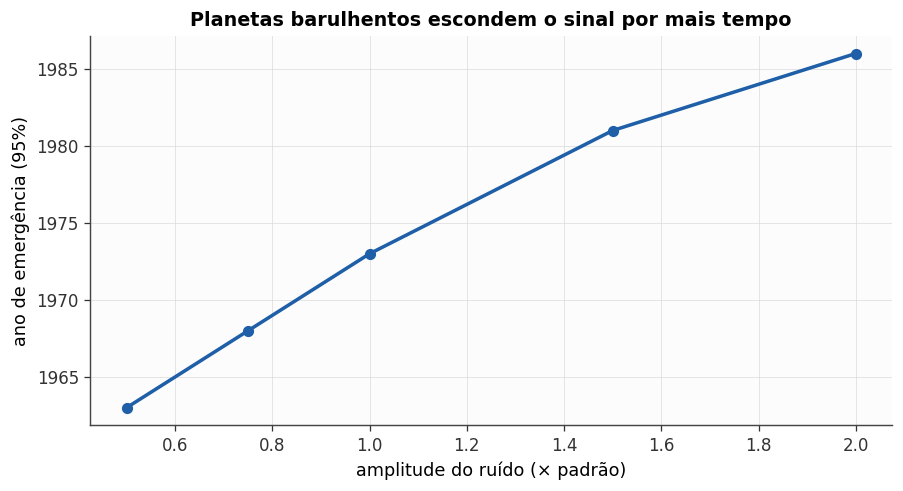

ruido x0.5: emergencia ~ 1963 (13 anos de dados)
ruido x0.75: emergencia ~ 1968 (18 anos de dados)
ruido x1.0: emergencia ~ 1973 (23 anos de dados)
ruido x1.5: emergencia ~ 1981 (31 anos de dados)
ruido x2.0: emergencia ~ 1986 (36 anos de dados)

e o mapa real da emergencia: tropicos (ruido pequeno) ja sentem o sinal
local; latitudes medias tempestuosas demoram mais — deteccao e razao S/N.


In [7]:
rng = np.random.default_rng(44)
anos = np.arange(1950, 2101); n = anos.size
tend = 0.02

def ano_emergencia(fator_ruido, n_planetas=60):
    def serie():
        r = np.zeros(n); phi, sig = 0.6, 0.11*fator_ruido
        for k in range(1, n):
            r[k] = phi*r[k-1] + sig*rng.standard_normal()
        return tend*(anos - anos[0]) + r
    series = [serie() for _ in range(n_planetas)]
    for m in range(12, n):
        x = anos[:m] - anos[0]
        ok = 0
        for s in series:
            p, cov = np.polyfit(x, s[:m], 1, cov=True)
            ok += p[0]/np.sqrt(cov[0, 0]) > 2
        if ok/n_planetas > 0.95:
            return anos[m]
    return anos[-1]

fatores = [0.5, 0.75, 1.0, 1.5, 2.0]
emerg = [ano_emergencia(f) for f in fatores]
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(fatores, emerg, 'o-', ms=6, color=CORES['azul'])
ax.set(xlabel='amplitude do ruído (× padrão)', ylabel='ano de emergência (95%)',
       title='Planetas barulhentos escondem o sinal por mais tempo')
plt.show()
for f, e in zip(fatores, emerg):
    print(f'ruido x{f}: emergencia ~ {e} ({e - 1950} anos de dados)')
print()
print('e o mapa real da emergencia: tropicos (ruido pequeno) ja sentem o sinal')
print('local; latitudes medias tempestuosas demoram mais — deteccao e razao S/N.')

---
*Material derivado de R. Stull, Practical Meteorology (CC BY-NC-SA 4.0); este notebook herda a mesma licença.*